# **LeNet**

In [ ]:
pip install --user tqdm # 진행바를 가시화

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms # 이미지 변환(전처리)
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os # 파일 경로에 대한 함수 제공
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm
import random
from matplotlib import pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([   # 이미지를 변형할 수 있는 방식들의 묶음
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),  # 주어진 확률로 이미지를 수평 반전( 기본값 0.5)
                transforms.ToTensor(),
                # PIL 형식 : 이미지의 범위 [0, 255], (높이x너비x채널) 을 torch.FloatTensor 배열로 바꿈
                # 이때 이미지의 범위 [0.0, 1.0] 이고 차원의 순서 (채널수x높이x너비)
                transforms.Normalize(mean, std)
                 # 사전 훈련 모델을 사용할 때는 ImageNet 데이터의 각 채널별 평균과 표준편차 맞게 정규화가 필요함
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    # __init__과 같은 들여쓰기 레벨로 맞춰줍니다.
    def __call__(self, img, phase):
        return self.data_transform[phase](img)

In [ ]:
# API 토큰 설정
os.environ['KAGGLE_API_TOKEN'] = "KGAT_e8e62cb7bb85abd8d25748922bf40184"

# 공개 데이터셋 다운로드 (별도 규정 동의 불필요)
!kaggle datasets download -d chetankv/dogs-cats-images

# dataset 폴더에 압축 해제
!unzip -q dogs-cats-images.zip -d ./dataset

Dataset URL: https://www.kaggle.com/datasets/chetankv/dogs-cats-images
License(s): CC0-1.0
dogs-cats-images.zip: Skipping, found more recently modified local copy (use --force to force download)
replace ./dataset/dataset/test_set/cats/cat.4001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
# 이미지 데이터셋을 불러온 후 훈련, 검증, 테스트로 분리

cat_directory = './dataset/dataset/training_set/cats'
dog_directory = './dataset/dataset/training_set/dogs'

# sorted : 데이터를 정렬된 리스트로 반환, os.path.join : 경로 파일명을 결합하거나 분할된 경로
# os.listdir : 지정한 디렉터리 내 모든 파일의 리스트 반환
cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory) if not f.startswith('.')])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory) if not f.startswith('.')])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]

# 손상되지 않은 정상 이미지 검증 : None(더 이상 데이터를 찾을 수 없을 때)까지 cv2.imread(i)를 통해 모든 이미지 데이터를 읽음
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

# 모듈이 호출될 때마다 임의의 난수 재생성. 그러나 시드값을 지정하면 그 시드값에 대해서는 동일한 값을 가짐.
random.seed(42)
random.shuffle(correct_images_filepaths)

# 데이터셋 분할
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:514]
test_images_filepaths = correct_images_filepaths[514:571]

print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 114 57


In [ ]:
# 테스트 데이터셋 이미지 확인 함수

def display_image_grid(images_filepaths, predicted_labels=(), cols=5) :
  rows = len(images_filepaths) // cols
  figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
  for i, image_filepath in enumerate(images_filepaths) :
    image = cv2.imread(image_filepath)
    ax.ravel()[i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) # cv2.COLOR_BGR2RGB는 변환할 이미지의 색상을 지정하는 것으로 BGR을 RGB로

    # 이미지의 전체 경로를 정규화하고 분할을 위한 코드
    # os.path.normpath : 경로명을 정규화, split(os.step) : 경로를 / 혹은 \ 을 기준으로 분할 (예를 들어 c:/temp/user 경로인데 user 반환)
    true_label = os.path.normpath(image_filepath).split(os.sep)[-2]

    # predicted_label에 대한 값을 정의하기 위한 코드
    # predicted_label 값이 있으면 그 값을 predicted_label라고 사용하고, 없다면 true_label을 predicted label로 사용
    predicted_label = predicted_labels[i] if predicted_labels else true_label
    color = "green" if true_label == predicted_label else "red" # 예측과 정답이 동일하면 초록색으로 표시하고, 그렇지 않으면 빨간색
    ax.ravel()[i].imshow(image)
    ax.ravel()[i].set_title(predicted_label, color=color) # predicted_label을 타이틀로 사용
    ax.ravel()[i].set_axis_off()
  plt.tight_layout()
  plt.show()

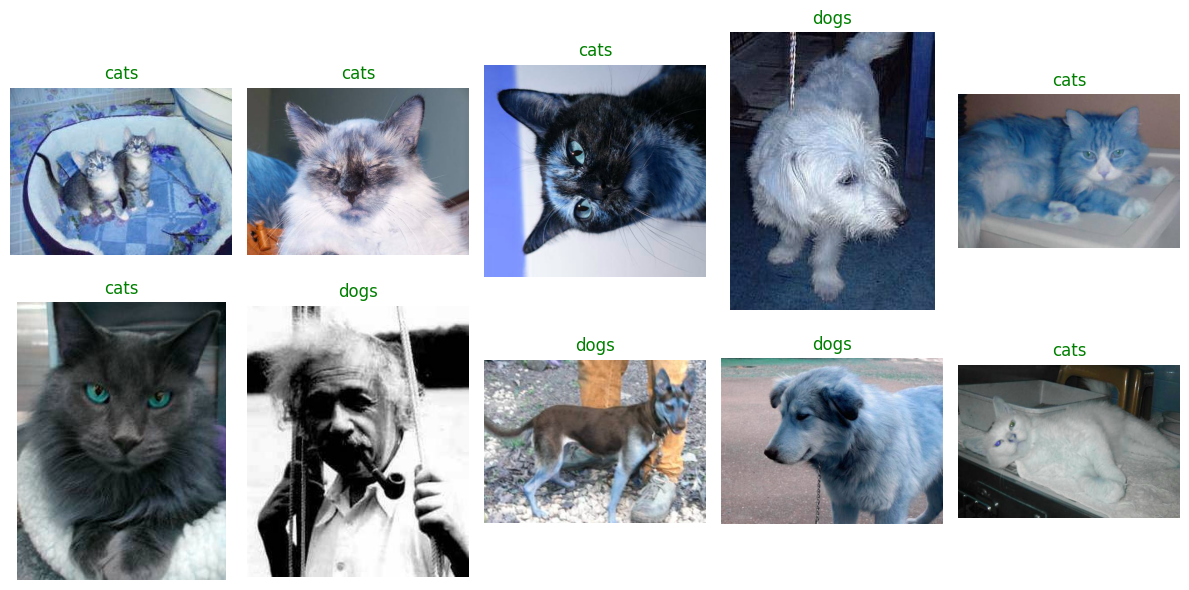

In [ ]:
# 테스트 데이터셋 이미지 출력

display_image_grid(test_images_filepaths[:10])

In [ ]:
class DogCatDataset(Dataset):
    def __init__(self, filepaths, transform=None, phase='train'):
        # filepaths로 들어온 매개변수를 self.file_list에 저장
        self.file_list = filepaths
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)

        if self.transform:
            img_transformed = self.transform(img, self.phase)
        else:
            img_transformed = img
        path_lower = img_path.lower()
        if 'dog' in path_lower:
            label = 1
        else:
            label = 0

        return img_transformed, label

In [ ]:
# 변수 값 정의

size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [ ]:
# 이미지 데이터셋 정의

train_dataset = DogCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
print(train_dataset.__getitem__(index)[0].size()) # trn 데이터의 크기(size()) 출력
print(train_dataset.__getitem__(index)[1]) # trn 데이터의 레이블 출력

torch.Size([3, 224, 224])
1


In [ ]:
# 데이터로더 정의

# DataLoader의 파라미터 : 첫번째=불러올 데이터, 두 번쨰 = 한 번에 메모미로 불러올 데이터 크기
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train':train_dataloader, 'val':val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1,
        0, 1, 1, 0, 0, 0, 1, 1])


In [ ]:
# 모델의 네트워크 클래스

class LeNet(nn.Module) :
  def __init__(self) :
    super(LeNet, self).__init__()
    # 입력 형태 (3, 244, 244), 출력 형태는 공식에 따라 (16, 220, 220)
    self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0)
    self.relu1 = nn.ReLU()
    # 출력 형태 (16, 220/2, 220/2) = (16, 110, 110)
    self.maxpool1 = nn.MaxPool2d(kernel_size=2)

    # 출력 형태 (32, 106, 106)
    self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
    self.relu2 = nn.ReLU()
    # 출력 형태 (32, 53, 53)
    self.maxpool2 = nn.MaxPool2d(kernel_size=2)

    self.fc1 = nn.Linear(32*53*53, 512)
    self.relu5 = nn.ReLU()
    self.fc2 = nn.Linear(512, 2)
    self.output = nn.Softmax(dim=1)

  def forward(self, x) :
    out = self.cnn1(x)
    out = self.relu1(out)
    out = self.maxpool1(out)
    out = self.cnn2(out)
    out = self.relu2(out)
    out = self.maxpool2(out)
    out=out.view(out.size(0), -1) # fc 전달 전에 데이터 형태를 1차원으로 바꿈
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.output(out)
    return out

In [ ]:
model = LeNet()
print(model)

LeNet(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=89888, out_features=512, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (output): Softmax(dim=1)
)


In [ ]:
pip install torchsummary

In [ ]:
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 220, 220]           1,216
              ReLU-2         [-1, 16, 220, 220]               0
         MaxPool2d-3         [-1, 16, 110, 110]               0
            Conv2d-4         [-1, 32, 106, 106]          12,832
              ReLU-5         [-1, 32, 106, 106]               0
         MaxPool2d-6           [-1, 32, 53, 53]               0
            Linear-7                  [-1, 512]      46,023,168
            Linear-8                    [-1, 2]           1,026
           Softmax-9                    [-1, 2]               0
Total params: 46,038,242
Trainable params: 46,038,242
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 19.47
Params size (MB): 175.62
Estimated Total Size (MB): 195.67
--------------------------------

In [ ]:
# 옵티마이저와 손실함수 정의

optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
 # model.parameters()는 summary를 통해서 46,038,242개임을 확인할 수 있음
criterion = nn.CrossEntropyLoss()

In [ ]:
# 모델의 파라미터와 손실 함수를 CPU에 할당

model = model.to(device)
criterion = criterion.to(device)

In [ ]:
import copy

def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since = time.time()
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epoch):
        print('Epoch {}/{}'.format(epoch + 1, num_epoch))
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            epoch_loss = 0.0
            epoch_corrects = 0

            for inputs, labels in tqdm(dataloader_dict[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                epoch_loss += loss.item() * inputs.size(0)
                epoch_corrects += torch.sum(preds == labels.data)

            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset)
            epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())


    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:.4f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

In [ ]:
# 모델 학습

import time

num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/tmp/ipykernel_1134/1569463673.py:21: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6774 Acc: 0.5850


  0%|          | 0/4 [00:00<?, ?it/s]

...

val Loss: 0.6701 Acc: 0.5702
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6388 Acc: 0.6275


  0%|          | 0/4 [00:00<?, ?it/s]

val Loss: 0.6685 Acc: 0.6228
Training complete in 5m 59s
Best val Acc: 0.6316


In [ ]:
import pandas as pd

id_list = []
pred_list = []
with torch.no_grad(): # 역전파 중 텐서들에 대한 변화도를 계산할 필요가 없음을 나타내는 것
    for test_path in tqdm(test_images_filepaths):
        img = Image.open(test_path)
        _id = test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0) # 텐서에 차원을 (0)에 추가
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist()
        # softmax는 지정된 차원을 따라 텐서의 요소가 범위가 있고 합계가 1이 되도록 크기를 다시 조정
        # output, dim=1 : softmax를 적용하여 각 행의 합이 1이 되도록 한다.
        # [:, 1] : 위의 모든 값 중 모든 행(:)에서 두 번쨰 칼럼을 가져온다.
        # tolist() : 배열을 리스트 형태로 변환
        id_list.append(_id)
        pred_list.append(preds [0])
res = pd. DataFrame({
'id': id_list,
'label': pred_list
}) # 테스트 데이터셋의 예측 결과인 id와 label을 데이터 프레임에 저장

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)
res.to_csv('../LeNet', index=False) # 데이터 프레임을 csv 파일로 저장


/tmp/ipykernel_1134/1800627522.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths):


  0%|          | 0/57 [00:00<?, ?it/s]

In [ ]:
# 테스트 데이터셋의 예측 결과 호출

res.head(10)

,id,label
0,1051,0.437855
1,1061,0.603990
2,1097,0.518452
3,1111,0.455595
4,1152,0.432294
5,1157,0.394624
6,1159,0.327164
7,1215,0.440022
8,1298,0.406830
9,1299,0.363642


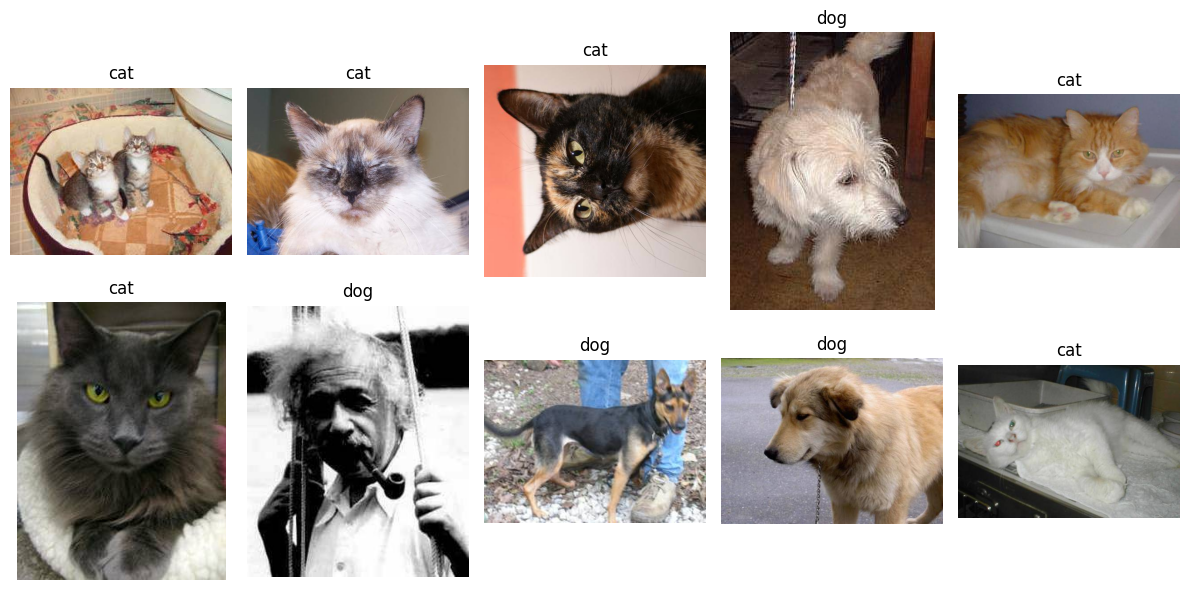

In [ ]:
import matplotlib.pyplot as plt
import cv2

class_ = {0: 'cat', 1: 'dog'} # 클래스 정의

def display_image_grid(images_filepaths, predicted_labels=None, cols=5):
    # 이미지 개수에 맞게 행(rows) 수 계산
    num_images = len(images_filepaths)
    rows = (num_images + cols - 1) // cols  # 나머지가 있어도 행이 부족하지 않도록 계산

    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 3 * rows))

    # ax가 1차원 배열이 아닐 경우를 대비해 ravel() 처리
    axes = ax.ravel() if num_images > 1 else [ax]

    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        axes[i].imshow(image)

        # 예측 라벨 값이 넘어온 경우 해당 라벨 표시, 없으면 파일 경로에서 힌트 추출
        if predicted_labels is not None and i < len(predicted_labels):
            label_idx = predicted_labels[i]
            axes[i].set_title(class_[label_idx])
        else:
            # 파일 경로에 'dog'가 있으면 1, 없으면 0
            label_idx = 1 if 'dog' in image_filepath.lower() else 0
            axes[i].set_title(class_[label_idx])

        axes[i].axis('off')

    # 남아있는 빈 서브플롯 안보이게 처리
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

display_image_grid(test_images_filepaths[:10])

# **AlexNet**

데이터 전처리, 분리, 커스텀데이터셋 정의, 변수(mean, std 등)에 대한 값 정의, 메모리에 불러오는 등의 과정 모두 LeNet의 코드를 써서 진행한다. 즉 AlexNet 모델 정의와 학습만 진행

In [ ]:
class AlexNet(nn.Module) :
  def __init__(self) -> None :
    super(AlexNet, self).__init__()
    self.features =nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
        nn. ReLU(inplace=True),
        # inplace : 연산에 대한 결과값을 새로운 변수에 저장하는 것이 아닌 기존 데이터를 대체
        # 즉 기존 값을 연산 결과값으로 대체함으로써 기존 값들을 무시
        nn. MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(64, 192, kernel_size=5, padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(192, 384, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(384, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
    )
    self. avgpool = nn.AdaptiveAvgPool2d((6,6))
    self.classifier = nn.Sequential (
        nn.Dropout(),
        nn.Linear(256*6*6, 4906),
        nn.ReLU(inplace=True),
        nn.Dropout(),
        nn.Linear(4906, 512),
        nn.ReLU(inplace=True),
        nn.Linear(512, 2),
    )
  def forward(self, x:torch.Tensor) -> torch.Tensor :
    x = self.features(x)
    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)
    return x

In [ ]:
model2 = AlexNet()
model2.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4906, bias=True)
 

In [ ]:
optimizer = optim.SGD(model2.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

In [ ]:
summary(model2, input_size = (3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 63, 63]          23,296
              ReLU-2           [-1, 64, 63, 63]               0
         MaxPool2d-3           [-1, 64, 31, 31]               0
            Conv2d-4          [-1, 192, 31, 31]         307,392
              ReLU-5          [-1, 192, 31, 31]               0
         MaxPool2d-6          [-1, 192, 15, 15]               0
            Conv2d-7          [-1, 384, 15, 15]         663,936
              ReLU-8          [-1, 384, 15, 15]               0
            Conv2d-9          [-1, 256, 15, 15]         884,992
             ReLU-10          [-1, 256, 15, 15]               0
           Conv2d-11          [-1, 256, 15, 15]         590,080
             ReLU-12          [-1, 256, 15, 15]               0
        MaxPool2d-13            [-1, 256, 7, 7]               0
AdaptiveAvgPool2d-14            [-1, 25

모델 학습 함수는 LeNet 함수 그대로 활용

In [ ]:
num_epoch =10
model2 = train_model(model2, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/tmp/ipykernel_1134/1569463673.py:21: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6935 Acc: 0.4925


  0%|          | 0/4 [00:00<?, ?it/s]

...

val Loss: 0.6931 Acc: 0.4737
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6925 Acc: 0.5125


  0%|          | 0/4 [00:00<?, ?it/s]

val Loss: 0.6931 Acc: 0.4737
Training complete in 7m 47s
Best val Acc: 0.5965


In [ ]:
# 모델을 이용한 예측

id_list = []
pred_list = []
with torch.no_grad():
    for test_path in tqdm(test_images_filepaths):
        img = Image.open(test_path)
        _id = test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model2(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist()
        id_list.append(_id)
        pred_list.append(preds [0])
res = pd. DataFrame({
'id': id_list,
'label': pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)
res.to_csv('../AlexNet', index=False) # 데이터 프레임을 csv 파일로 저장


/tmp/ipykernel_1134/3340288768.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths):


  0%|          | 0/57 [00:00<?, ?it/s]

In [ ]:
# 데이터 프레임 결과 확인

res.head(10)

,id,label
0,1051,0.437855
1,1061,0.603990
2,1097,0.518452
3,1111,0.455595
4,1152,0.432294
5,1157,0.394624
6,1159,0.327164
7,1215,0.440022
8,1298,0.406830
9,1299,0.363642


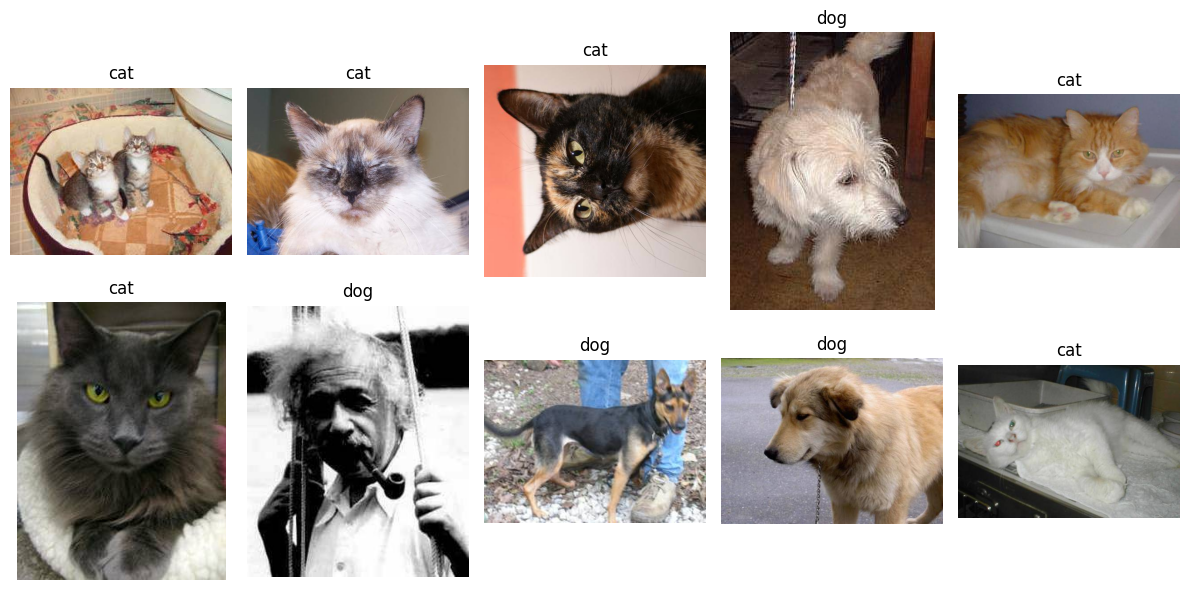

In [ ]:
# 예측 결과를 시각적으로 표현하기 위한 함수 정의


class_ = {0: 'cat', 1: 'dog'}

def display_image_grid(images_filepaths, predicted_labels=None, cols=5):
    num_images = len(images_filepaths)
    rows = (num_images + cols - 1) // cols

    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 3 * rows))

    axes = ax.ravel() if num_images > 1 else [ax]

    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        axes[i].imshow(image)


        if predicted_labels is not None and i < len(predicted_labels):
            label_idx = predicted_labels[i]
            axes[i].set_title(class_[label_idx])
        else:
            label_idx = 1 if 'dog' in image_filepath.lower() else 0
            axes[i].set_title(class_[label_idx])

        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

display_image_grid(test_images_filepaths[:10])

# **VGGNet(VGG11)**

In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms # 이미지 변환(전처리)
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os # 파일 경로에 대한 함수 제공
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm
import random
from matplotlib import pyplot as plt
import copy # 객체 복사
import numpy as np
import torch.utils.data as data

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
class VGG(nn.Module):
    def __init__(self, features, output_dim):
        super().__init__()
        self.features = features
        self.avgpool = nn.AdaptiveAvgPool2d(7)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, output_dim)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.classifier(h)
        return x

In [3]:
# 모델 유형 정의

# VGG11 : 8(합성곱층) + 3 (풀링층) = 11(전체계층)
vgg11_config = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

# VGG13 : 10(합성곱층) + 3 (풀링층) = 13(전체계층)
vgg13_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

# VGG16 : 13(합성곱층) + 3 (풀링층) = 16(전체계층)
vgg16_config = [64, 64,'M', 128, 128,'M', 256, 256, 256,
                'M', 512, 512, 512, 'M', 512, 512, 512 , 'M']

# VGG19 : 16(합성곱층) + 3 (풀링층) = 11(전체계층)
vgg19_config = [64, 64,'M', 128, 128,'M', 256, 256, 256, 256,
                'M',512,  512, 512, 512, 'M',512,  512, 512, 512 , 'M']

In [4]:
# VGG 계층 정의

def get_vgg_layers(config, batch_norm) :
  layers = [  ]
  in_channels = 3

  for c in config : # vgg_config 값들을 가져온다
      assert c == 'M' or isinstance(c, int) # c가 M이 아니거나 int가 아니라면 오류 발생
      # c == 'M'이 아니면 오류가 발생한다.
      # isinstance는 주어진 조건이 True인지 확인한다

      if c == 'M' :  # 불러온 값이 M이면 최대 풀링 적용
          layers += [nn.MaxPool2d(kernel_size = 2)]
      else : # 불러온 값이 합성곱층이면
          conv2d = nn.Conv2d(in_channels, c, kernel_size = 3, padding=1)
          if batch_norm: # 배치 정규화를 적용할지에 대한 코드
            layers += [conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
          else :
            layers += [conv2d, nn.ReLU(inplace=True)]
          in_channels = c
  return nn.Sequential(*layers) # 네트워크의 모든 계층을 반환

In [5]:
# 모델 계층 생성
vgg11_layers = get_vgg_layers(vgg11_config, batch_norm=True)

In [6]:
print(vgg11_layers)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

In [7]:
# VGG11 전체에 대한 네트워크

OUTPUT_DIM = 2 # 개와 고양이 두 개의 클래스 사용
model = VGG(vgg11_layers, OUTPUT_DIM)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [8]:
# VGG11 사전 훈련된 모델 사용

import torchvision.models as models
pretrained_model = models.vgg11_bn(pretrained=True)
print(pretrained_model)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [9]:
# 이미지에 대한 전처리

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(5), # 5도 이하로 이미지를 회전한다.
    transforms. RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229,
    0.224, 0.225])])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229,
    0.224, 0.225])])

In [10]:
import torchvision
from torch.utils.data import Subset

train_path = './dataset/dataset/training_set'
test_path = './dataset/dataset/test_set'

full_train_dataset = torchvision.datasets.ImageFolder(
    train_path,
    transform=train_transforms
)

full_test_dataset = torchvision.datasets.ImageFolder(
    test_path,
    transform=test_transforms
)

train_dataset = Subset(full_train_dataset, range(529))
test_dataset = Subset(full_test_dataset, range(12))


print(len(train_dataset)), print(len(test_dataset))

529
12


(None, None)

In [11]:
# 훈련과 검증 데이터 분할
import torch.utils.data as data

VALID_RATIO = 0.9
n_train_examples = int(len(train_dataset) * VALID_RATIO)
n_valid_examples = len(train_dataset) - n_train_examples

# random_split()은 훈련과 검증 데이터셋을 나누는 용도로 사용한다.
# 첫 번째 파라 : 분할에 사용될 데이터셋, 두 번째 파라 : 훈련과 검증 데이터셋의 크기 지정[훈련, 검증]
train_data, valid_data = data.random_split(train_dataset,
                                           [n_train_examples, n_valid_examples])

In [12]:
# 검증 데이터 전처리

valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

In [13]:
print(f'훈련 데이터셋 : {len(train_data)}')
print(f'검증 데이터셋 : {len(valid_data)}')
print(f'테스트 데이터셋 : {len(test_dataset)}')

훈련 데이터셋 : 476
검증 데이터셋 : 53
테스트 데이터셋 : 12


In [14]:
# 메모리로 데이터 불러오기

BATCH_SIZE = 32
train_iterator = data.DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)
valid_iterator = data.DataLoader(valid_data, batch_size=BATCH_SIZE)
test_iterator = data.DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [15]:
# 옵티마이저와 손실 함수 정의

optimizer = optim.Adam(model.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [16]:
# 모델 정확도 측정 함수

def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)

    # 예측과 정답이 일치하는 경우 그 개수의 합을 correct 변수에 저장
    # top_pred.eq ; eq는 equal의 약자로 서로 같은지를 비교한다
    # y.view_as(top_pred) : y에 대한 텐서 크기를 top_pred의 텐서 크기로 변경하겠다는 의미
    # sum() : 합계를 구하는 것으로, 여기에서는 에측과 정답이 일치하는 것들의 개수를 합산
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

In [17]:
# 모델 학습 함수 정의

def train(model, iterator, optimizer, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  model.train()
  for (x, y) in iterator:
    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred, y)
    acc = calculate_accuracy(y_pred, y)

    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
    epoch_acc += acc.item()
  return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [18]:
# 모델 성능 측정 함수

def evaluate(model, iterator, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  model.eval()
  with torch.no_grad():
    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)
        y_pred = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)
        epoch_loss += loss.item()
        epoch_acc += acc.item()
  return epoch_loss / len(iterator), epoch_acc / len(iterator)


In [19]:
# 학습 시간 측정 함수

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
# 모델 학습

import time

EPOCHS = 5
best_valid_loss = float('inf')

for epoch in range(EPOCHS):
    start_time = time.time()
    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device) # 훈련 데이터셋을 모델에 적용한 결과를 train_loss와 train_acc에 저장
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device) # 검증 데이터셋을 모델에 적용한 결과를 train_loss와 train_acc에 저장

    if valid_loss < best_valid_loss : # valid_loss가 가장 작은 값을 구하고, 그 상태의 모델을 VGG-model.pt로 저장
      best_valid_loss = valid_loss
      torch.save(model.state_dict(), '../VGG-model.pt')
    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

Epoch: 01 | Epoch Time: 13m 7s
	Train Loss: 0.481 | Train Acc: 98.12%
	 Val. Loss: 0.576 |  Val. Acc: 100.00%


In [21]:
# 테스트 데이터셋을 이용한 모델 성능 측정

model.load_state_dict(torch.load('../VGG-model.pt'))
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Test Loss: 0.653 | Test Acc: 100.00%


In [33]:
# 테스트 데이터셋을 이용한 모델의 예측 확인 함수

def get_predictions (model, iterator):
    model.eval()
    images = [ ]
    labels = [ ]
    probs = []

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y_pred = model(x)
            y_prob = F.softmax(y_pred, dim=-1)
            top_pred = y_prob.argmax(1, keepdim=True) # argmax는 배열에서 가장 큰 값의 index를 찾는다
            # 첫 번째 파라 : 행(0) 또는 열(1)에서 찾으라는 뜻으로, 열을 따라 가장 큰 값을 찾으라는 뜻
            # keepdim=True의 경우 출력 텐서를 입력과 동일 크기로 유지하겠다는 의미
            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())
    images = torch.cat(images, dim=0) # torch.cat으로 텐서 연결
    labels = torch.cat(labels, dim=0)
    probs = torch.cat(probs, dim=0)
    return images, labels, probs

In [34]:
# 예측 중에서 정확하게 예측한 것을 추출

images, labels, probs = get_predictions(model, test_iterator)
pred_labels = torch.argmax(probs, 1)
corrects = torch.eq(labels, pred_labels) # 예측과 정답이 같은지 비교
correct_examples = [ ]

# zip()은 여러 개의 리스트(혹은 튜플)를 합쳐서 새로운 튜플 타입으로 반환
for image, label, prob, correct in zip(images, labels, probs, corrects):
    if correct:
        correct_examples.append((image, label, prob))
# 데이터를 정렬하기 위해 sort() 메서드를 사용
# reverse=True : 내림차순으로 정렬
correct_examples.sort(reverse=True, key=lambda x: torch.max(x[2], dim=0).values)

In [24]:
# 이미지 출력을 위한 전처리

def normalize_image(image):
  image_min = image.min()
  image_max = image.max()
  image.clamp_(min=image_min, max=image_max) # torch.clamp는 주어진 최소 최대의 범주에 이미지가 위치하도록 한다
  # torch.add는 새로운 공간을 할당하여 저장되고, torch.add_는 새로운 공간할당 없이 기존의 메모리에 위치한 값을 대체한다
  image.add_(-image_min).div_(image_max-image_min+1e-5)
  return image

In [27]:
import matplotlib.pyplot as plt

In [30]:
# 모델이 정확하게 예측한 이미지 출력 함수

def plot_most_correct(correct, classes, n_images, normalize=True):
    rows = int(np.sqrt(n_images)) # nq.sqrt는 제곱근을 게산
    cols = int(np.sqrt(n_images))
    fig = plt.figure(figsize=(25,20))
    for i in range(rows*cols):
        ax = fig.add_subplot(rows, cols, i+1)  # 출력하려는 그래프 개수만큼 subplot을 만든다
        image, true_label, probs = correct[i]
        image = image.permute(1, 2, 0) # image.permute으로 축 변경
        true_prob = probs [true_label]
        correct_prob, correct_label = torch.max(probs, dim=0)
        true_class = classes [true_label]
        correct_class = classes[correct_label]

        if normalize: # 본애 이미지대로 출력하기 위해 normalize_image 함수 호출
            image = normalize_image(image)
        ax.imshow(image.cpu().numpy())
        ax.set_title(f'true label: {true_class} ({true_prob:.3f})\n'\
          f'pred label: {correct_class} ({correct_prob:.3f})')
        ax.axis('off')

    fig.subplots_adjust(hspace=0.4)

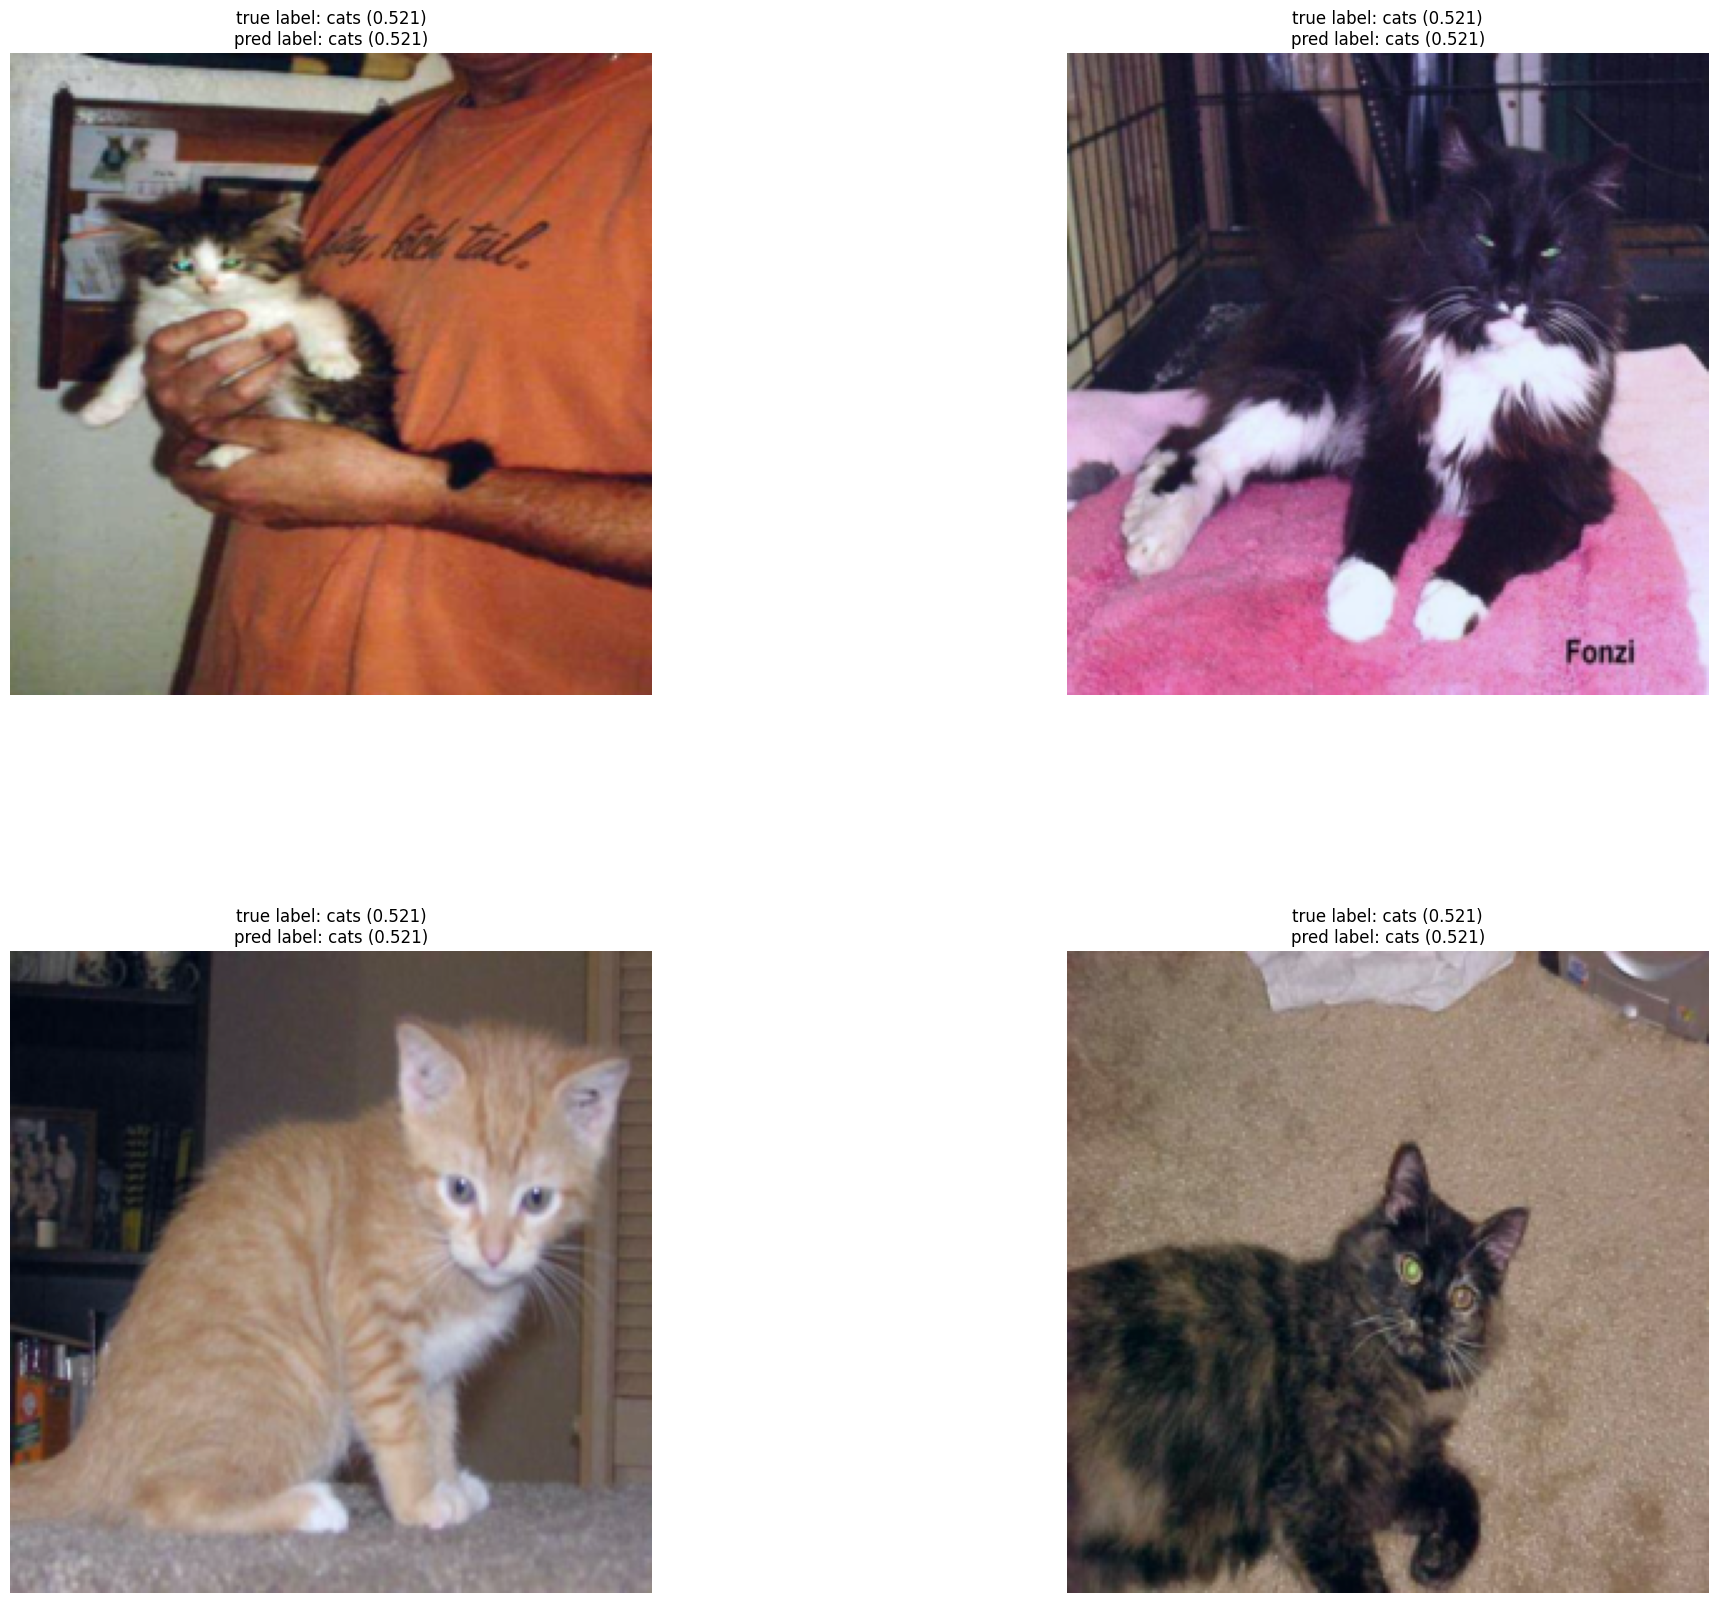

In [35]:
# 예측 결과 이미지 출력

classes = ['cats', 'dogs']
N_IMAGES = 5
plot_most_correct(correct_examples, classes, N_IMAGES)